## Fidelity of MPDO from sequential circuit

In [78]:
include("evolMPDO.jl")

optimize_overlap_twofloor_sweep (generic function with 2 methods)

In [2]:
include("IsingED.jl")

compute_fidelity (generic function with 1 method)

In [3]:
using Plots

## Ising GS + X dephasing - exact fidelity

In [5]:
N = 8;
h = 1.0; # slightly off critical
Es, psis = get_Ising_eigenstates(N,h);
@show Es[1]
psi_gs = psis[:,1];

Es[1] = -10.251661790965976


In [5]:
p1 = 0.2;
p2 = 0.4;
rho1 = apply_channel!(psi_gs*psi_gs',dephasing_X(p1),N)
rho2 = apply_channel!(psi_gs*psi_gs',dephasing_X(p2),N);

In [6]:
compute_fidelity(rho1,rho2) # ||sqrt(rho1)*sqrt(rho2)||_1 exact fidelity

0.9548648739272491

In [6]:
tr(rho1*rho2)/sqrt(tr(rho1^2)*tr(rho2^2)) # overlap in Hilbert-Schmidt norm

0.9309468777247031

## Ising GS + X dephasing - MPDO optimization

In [6]:
N = 8;
h = 1.0;
# psiMPS = Ising_GS_DMRG(N,h);
psiMPS = Ising_GS_DMRG(N,h, false); # the last parameter is boundary condition

After sweep 1 energy=-9.814897090002386  maxlinkdim=16 maxerr=9.80E-11 time=22.604
After sweep 2 energy=-9.837816066807228  maxlinkdim=15 maxerr=9.52E-11 time=0.008
After sweep 3 energy=-9.837951442705108  maxlinkdim=7 maxerr=9.89E-11 time=0.030
After sweep 4 energy=-9.837951446198693  maxlinkdim=6 maxerr=7.40E-11 time=0.007
After sweep 5 energy=-9.837951446199051  maxlinkdim=6 maxerr=6.97E-11 time=0.015
After sweep 6 energy=-9.83795144619905  maxlinkdim=6 maxerr=6.91E-11 time=0.241
After sweep 7 energy=-9.837951446199051  maxlinkdim=6 maxerr=6.91E-11 time=0.022
After sweep 8 energy=-9.83795144619905  maxlinkdim=6 maxerr=6.91E-11 time=0.019
After sweep 9 energy=-9.837951446199042  maxlinkdim=6 maxerr=6.91E-11 time=0.033
After sweep 10 energy=-9.83795144619905  maxlinkdim=6 maxerr=6.91E-11 time=0.008
After sweep 11 energy=-9.837951446199064  maxlinkdim=6 maxerr=6.91E-11 time=0.008
After sweep 12 energy=-9.837951446199057  maxlinkdim=6 maxerr=6.91E-11 time=0.005
After sweep 13 energy=-9.

In [7]:
M_GS = myMPS(MPS_to_array(psiMPS));
# M.TensorList

myMPS{Float64}([[0.9624124249815013 2.4659830008434976e-16;;; -6.906607100567739e-17 0.2715922020994456], [-0.9565072018710068 -3.407190334123044e-16; 2.7509925245818604e-16 -0.8524385917565891;;; -5.197463792301333e-17 -0.2916499306548115; -0.5210517935874962 2.3913425140096907e-16;;; 2.279595266019246e-16 -0.005763797040856275; 0.04051142213870454 -7.770146892824931e-16;;; -0.001034099421099031 8.81116988018425e-17; -1.426763057315192e-16 0.014570530518681478], [0.9551823012232593 3.427275458640573e-16; -2.417557250906038e-16 0.8271015137532023; -8.047827809740943e-16 0.5387918701740113; 0.27291267257965607 4.627902319617886e-14;;; 3.785875551276332e-17 0.29584607428545706; 0.55975856410885 -2.5663835748505076e-16; -0.7640820705351263 2.6669943143067904e-15; -7.620353062493353e-14 -0.8928453716691157;;; 1.2281484454224202e-16 -0.009934922803701656; 0.047090105362268334 -2.5115760268487637e-16; -0.3356910885411058 -1.437649340878237e-14; -2.8558971245021695e-14 -0.32008910538543484;;;

In [68]:
p1 = 0.2;
p2 = 0.4; # Get the two noisy states
Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(M_GS, Ws1)

Ws2 = Array{Float64,3}[purified_dephasing_channel(p2,[0,0,1]) for _ in 1:N]
M2 = add_noise_MPS(M_GS, Ws2);

M1_acl = add_ancillas(M1)
M2_acl = add_ancillas(M2)

myMPDO{Float64}([[0.8608078418596214 2.2056422484979926e-16;;; 0.4304039209298107 -1.1028211242489963e-16;;; 0.0 0.0;;; 0.0 0.0;;;; -6.177457188300876e-17 0.2429194504212886;;; -3.088728594150438e-17 -0.1214597252106443;;; 0.0 0.0;;; 0.0 0.0], [-0.855526049740674 -3.047483679751739e-16; 2.4605625162235204e-16 -0.76244425512477;;; -0.427763024870337 1.5237418398758694e-16; 1.2302812581117602e-16 0.381222127562385;;; 0.0 0.0; 0.0 0.0;;; 0.0 0.0; 0.0 0.0;;;; -4.6487529400718517e-17 -0.2608596282309033; -0.4660428921039322 2.1388817675243645e-16;;; -2.3243764700359258e-17 0.13042981411545165; -0.2330214460519661 -1.0694408837621822e-16;;; 0.0 0.0; 0.0 0.0;;; 0.0 0.0; 0.0 0.0;;;; 2.0389319904023002e-16 -0.005155296796746705; 0.0362345175069333 -6.949830659006127e-16;;; 1.0194659952011501e-16 0.0025776483983733526; 0.01811725875346665 3.4749153295030633e-16;;; 0.0 0.0; 0.0 0.0;;; 0.0 0.0; 0.0 0.0;;;; -0.0009249266404282454 7.880949925356264e-17; -1.276135673576879e-16 0.013032278683202822;;;

In [9]:
## Test for small sizes

M1dense = MPDO_to_dense(M1);
M2dense = MPDO_to_dense(M2);

rho1dense = M1dense*M1dense'
rho2dense = M2dense*M2dense'
F0 = compute_fidelity(rho1dense,rho2dense) 


0.9714929136468092

In [69]:
compute_overlap(M1,M2)  ## fidelity of purification without optimization

0.9223681599999998

In [79]:
M1cp,M2cp,ov_all = optimize_overlap(M1_acl,M2_acl,2); ## seems stuck!!!

----iteration 1 -----
debug
Bond dimensions: 13,10
Overlap: 0.9690906306546392
----iteration 2 -----
debug
Bond dimensions: 13,10
Overlap: 0.96909063618468


In [76]:
ov_all[1:5]

5-element Vector{Float64}:
 0.9223681599999991
 0.9349807875117336
 0.9401672541077994
 0.9452247408155448
 0.9503003553715833

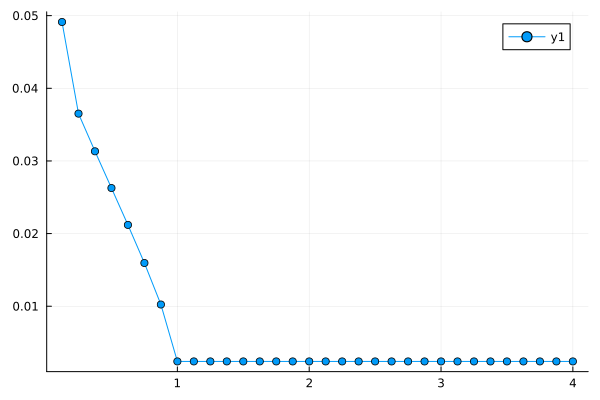

In [77]:
x = range(1,length(ov_all))./8
y = abs.(ov_all.-F0)
start = 1
plot(x[start:end], y[start:end], marker = :circle)

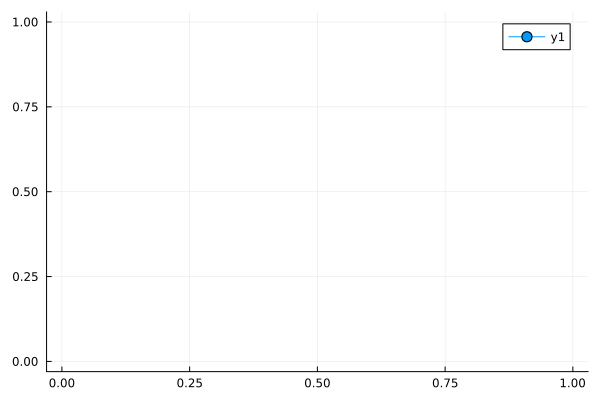

In [80]:
start = 50
plot(x[start:end], y[start:end], marker = :circle)

In [16]:
random_unitary_layer_ancilla_onsite!(M2);

In [17]:
compute_overlap(M1,M2)  ## fidelity of purification after random reshuffle

0.00026298698749295415

In [18]:
M1cp,M2cp,ov = optimize_overlap(M1,M2,5); ## still stuck!!!

----iteration 1 -----
Bond dimensions: 23,22
Overlap: 0.9309694035500862
----iteration 2 -----
Bond dimensions: 30,24
Overlap: 0.9317651780633927
----iteration 3 -----
Bond dimensions: 29,24
Overlap: 0.9317658871751253
----iteration 4 -----
Bond dimensions: 29,24
Overlap: 0.9317658875542371
----iteration 5 -----
Bond dimensions: 29,24
Overlap: 0.9317658875548928
